### PyTorch version and device parameters

In [2]:
import torch
import platform

print(f"PyTorch version: {torch.__version__}")
print(f"Platform: {platform.system()} {platform.release()}")
print(f"CPU: {platform.processor()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
Platform: Windows 10
CPU: Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


### evaluate_model

Processing valid data, saving to ./cache\valid_features.npz ...
  Cache saved to ./cache\valid_features.npz, sample count: 5010

--- Compute complexity metrics ---
Total trainable parameters: 30,425
Model size (FP32): 0.12 MB
Average inference latency per sample: 1.06 ms
----------------------------------



Inference: 100%|██████████| 10/10 [00:00<00:00, 127.03it/s]


Predictions saved to ./validation_result\validation_predictions.xlsx

Anomaly Detection Performance:
Temperature: Acc=0.9970, Prec=0.9797, Rec=0.9461, F1=0.9626
Turbidity: Acc=0.9828, Prec=0.9659, Rec=0.9948, F1=0.9801
Methane: Acc=0.9964, Prec=0.9944, Rec=0.9984, F1=0.9964
ORP: Acc=0.9982, Prec=1.0000, Rec=0.9728, F1=0.9862

Overall Fluid Type Accuracy: 0.9786
Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.96      0.98      1578
           2       0.97      0.99      0.98      2131
           3       1.00      0.92      0.96       122
           4       0.96      0.96      0.96       190
           5       0.98      0.99      0.98       989

    accuracy                           0.98      5010
   macro avg       0.98      0.96      0.97      5010
weighted avg       0.98      0.98      0.98      5010

Anomaly detection plot saved to ./validation_result\anomaly_detection_results.png


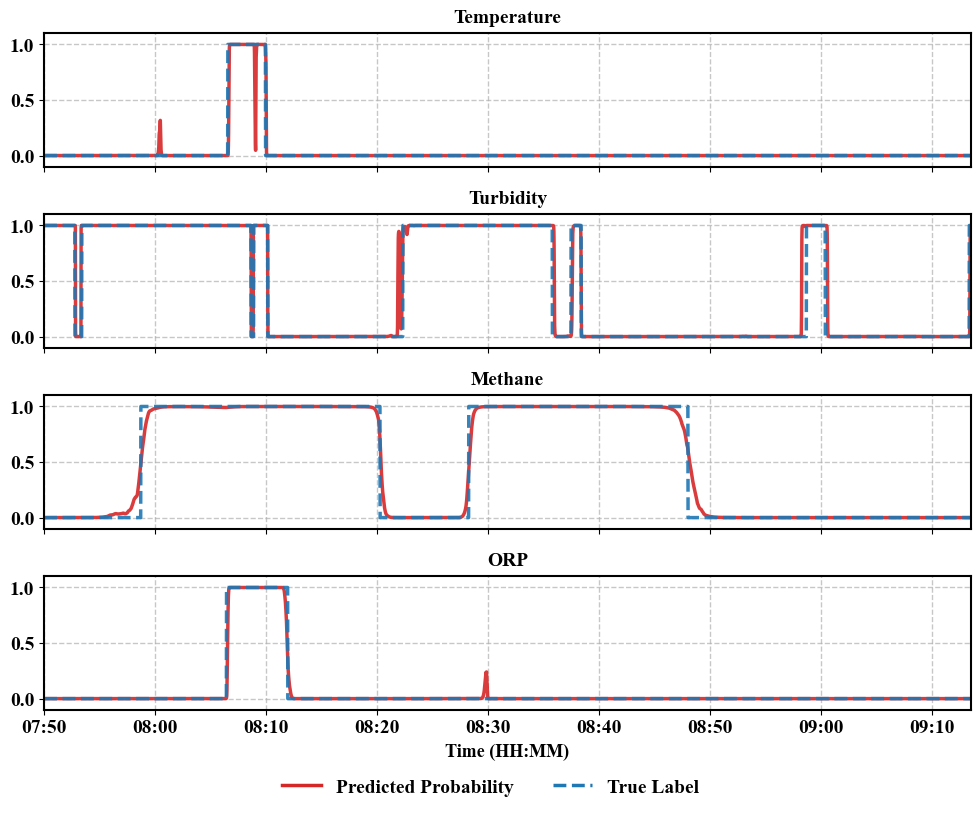

Confusion matrix plot saved to ./validation_result\fluid_type_confusion_matrix.png


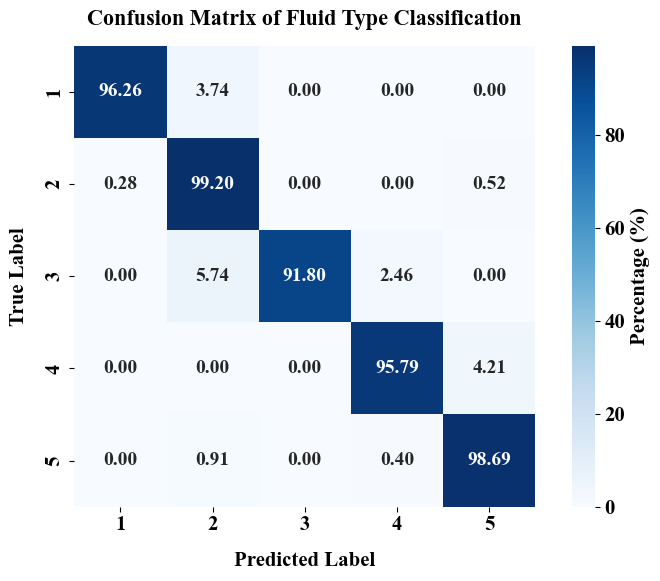

In [4]:
################################################################################
#                                                                              #
#                    Hydrothermal Plume Anomaly Detection                      #
#                          Model Evaluation Script                             #
#                                                                              #
# Revised: 2026.04.19                                                          #
#   - Load trained combined model (GRU anomaly detectors + MLP classifier)     #
#   - Evaluate on validation dataset and generate performance metrics          #
#   - Compute model complexity (parameters, size, inference latency)           #
#   - Visualize anomaly detection probabilities and confusion matrix           #
#   - Save all predictions to Excel for further analysis                       #
#                                                                              #
################################################################################

# evaluate_model.py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import os
import json
import time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
from numpy.lib.stride_tricks import sliding_window_view
from matplotlib.lines import Line2D

# ====================== Model Definitions ======================
class GRUCellAnomalyDetector(nn.Module):
    """GRU-based anomaly detector for a single sensor."""
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru_cells = nn.ModuleList()
        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size
            self.gru_cells.append(nn.GRUCell(in_size, hidden_size))
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, h=None):
        if h is None:
            h = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        new_h = []
        for i, cell in enumerate(self.gru_cells):
            h_i = h[i]
            out = cell(x if i == 0 else new_h[-1], h_i)
            new_h.append(out)
        last_out = new_h[-1]
        out = self.fc(last_out)
        return self.sigmoid(out), torch.stack(new_h)


class MLPClassifier(nn.Module):
    """MLP for plume type classification."""
    def __init__(self, input_size=4, hidden_size=64, num_layers=2, output_size=5):
        super().__init__()
        layers = []
        prev = input_size
        for _ in range(num_layers):
            layers.append(nn.Linear(prev, hidden_size))
            layers.append(nn.ReLU())
            prev = hidden_size
        layers.append(nn.Linear(prev, output_size))
        self.mlp = nn.Sequential(*layers)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        return self.softmax(self.mlp(x))


class CombinedModel(nn.Module):
    """Combined model: four GRU detectors + MLP classifier."""
    def __init__(self, gru_models, mlp_model):
        super().__init__()
        self.temp_detector = gru_models[0]
        self.turb_detector = gru_models[1]
        self.meth_detector = gru_models[2]
        self.orp_detector  = gru_models[3]
        self.mlp = mlp_model

    def forward(self, x_list, prev_hiddens=None):
        if prev_hiddens is None:
            prev_hiddens = [None, None, None, None]
        temp_prob, h_temp = self.temp_detector(x_list[0], prev_hiddens[0])
        turb_prob, h_turb = self.turb_detector(x_list[1], prev_hiddens[1])
        meth_prob, h_meth = self.meth_detector(x_list[2], prev_hiddens[2])
        orp_prob, h_orp   = self.orp_detector(x_list[3], prev_hiddens[3])
        anomaly_probs = [temp_prob, turb_prob, meth_prob, orp_prob]
        concat_probs = torch.cat(anomaly_probs, dim=1)
        fluid_probs = self.mlp(concat_probs)
        return anomaly_probs, fluid_probs, [h_temp, h_turb, h_meth, h_orp]


# ====================== Feature Extraction Functions ======================
def extract_features_temp_turb(seq, window_size):
    """Extract 8 statistical features for temperature and turbidity."""
    if len(seq) < window_size:
        return np.empty((0, 8), dtype=np.float32)
    windows = sliding_window_view(seq, window_size)
    mean = windows.mean(axis=1)
    std = windows.std(axis=1)
    median = np.median(windows, axis=1)
    q1 = np.percentile(windows, 25, axis=1)
    q3 = np.percentile(windows, 75, axis=1)
    iqr = q3 - q1
    minv = windows.min(axis=1)
    maxv = windows.max(axis=1)
    return np.column_stack([mean, std, median, q1, q3, iqr, minv, maxv]).astype(np.float32)


def extract_features_meth_orp(seq, window_size):
    """Extract 6 statistical features for methane and ORP."""
    if len(seq) < window_size:
        return np.empty((0, 6), dtype=np.float32)
    windows = sliding_window_view(seq, window_size)
    mean = windows.mean(axis=1)
    std = windows.std(axis=1)
    median = np.median(windows, axis=1)
    q1 = np.percentile(windows, 25, axis=1)
    q3 = np.percentile(windows, 75, axis=1)
    iqr = q3 - q1
    return np.column_stack([mean, std, median, q1, q3, iqr]).astype(np.float32)


# ====================== Dataset Class ======================
class HydrothermalDataset(Dataset):
    """Load raw data, extract sliding window features and cache them."""
    def __init__(self, data_dir, window_size, cache_key, cache_dir):
        self.window_size = window_size
        os.makedirs(cache_dir, exist_ok=True)
        cache_file = os.path.join(cache_dir, f"{cache_key}_features.npz")

        if os.path.exists(cache_file):
            try:
                data = np.load(cache_file)
                self.features = [data['feat_temp'], data['feat_turb'], data['feat_meth'], data['feat_orp']]
                self.anomaly_labels_aligned = data['anomaly_labels']
                self.plume_labels_aligned = data['plume_labels']
                self.time = data['time'] if 'time' in data else None
                print(f"Loaded cached {cache_key} data successfully")
                return
            except:
                print(f"Cache file corrupted, reprocessing {cache_key} data...")

        print(f"Processing {cache_key} data, saving to {cache_file} ...")
        feat_path = os.path.join(data_dir, 'real_time_data.xlsx')
        anom_path = os.path.join(data_dir, 'anomaly_labels.xlsx')
        plume_path = os.path.join(data_dir, 'plume_type_labels.xlsx')

        df_feat = pd.read_excel(feat_path)
        df_anom = pd.read_excel(anom_path)
        df_plume = pd.read_excel(plume_path)

        data = df_feat.iloc[:, 0:4].values.astype(np.float32)
        anomaly_labels = df_anom.values.astype(np.float32)
        plume_labels = df_plume.values.astype(np.float32)

        feat_temp = extract_features_temp_turb(data[:, 0], window_size)
        feat_turb = extract_features_temp_turb(data[:, 1], window_size)
        feat_meth = extract_features_meth_orp(data[:, 2], window_size)
        feat_orp = extract_features_meth_orp(data[:, 3], window_size)

        self.features = [feat_temp, feat_turb, feat_meth, feat_orp]
        T = self.features[0].shape[0]
        self.time = None
        self.anomaly_labels_aligned = anomaly_labels[window_size-1:, :]
        self.plume_labels_aligned = plume_labels[window_size-1:, :]

        save_dict = {
            'feat_temp': feat_temp, 'feat_turb': feat_turb,
            'feat_meth': feat_meth, 'feat_orp': feat_orp,
            'anomaly_labels': self.anomaly_labels_aligned,
            'plume_labels': self.plume_labels_aligned
        }
        np.savez(cache_file, **save_dict)
        print(f"  Cache saved to {cache_file}, sample count: {T}")

    def __len__(self):
        return self.features[0].shape[0]

    def __getitem__(self, idx):
        x_list = [torch.from_numpy(self.features[i][idx]) for i in range(4)]
        y_anom = torch.from_numpy(self.anomaly_labels_aligned[idx])
        y_plume = torch.from_numpy(self.plume_labels_aligned[idx])
        return x_list, y_anom, y_plume


# ====================== Evaluation Metrics ======================
def compute_anomaly_metrics(pred_probs, true_labels):
    """Compute accuracy, precision, recall and F1 for anomaly detection."""
    pred_binary = (pred_probs > 0.5).astype(int)
    TP = np.sum((pred_binary == 1) & (true_labels == 1))
    TN = np.sum((pred_binary == 0) & (true_labels == 0))
    FP = np.sum((pred_binary == 1) & (true_labels == 0))
    FN = np.sum((pred_binary == 0) & (true_labels == 1))
    total = TP + TN + FP + FN
    acc = (TP + TN) / total if total > 0 else 0
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0
    rec = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1_Score': f1}


# ====================== Plotting Functions ======================
def plot_anomaly_detection(pred_probs, true_labels, sensor_names, time_data, save_path,
                           font_family='Times New Roman', font_size_title=12, font_size_label=12,
                           font_size_ticks=10, font_size_legend=11, pred_color='#d62728',
                           true_color='#1f77b4', linewidth=2.5, dpi=600):
    """Plot predicted anomaly probabilities vs true labels for all four sensors."""
    plt.rcParams.update({
        'font.family': 'serif', 'font.serif': [font_family], 'font.size': font_size_label,
        'font.weight': 'bold', 'axes.linewidth': 1.5, 'grid.linewidth': 0.8,
        'grid.alpha': 0.3, 'savefig.dpi': dpi, 'figure.figsize': (10, 8)
    })
    # Convert Excel numeric dates to datetime if needed
    if isinstance(time_data[0], (int, float)):
        base_date = datetime(1899, 12, 30)
        time_dates = [base_date + timedelta(days=float(t)) for t in time_data]
    else:
        time_dates = time_data

    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    for idx, (name, pred, true) in enumerate(zip(sensor_names, pred_probs, true_labels)):
        ax = axes[idx]
        ax.plot(time_dates, pred, color=pred_color, linestyle='-', linewidth=linewidth, alpha=0.9)
        ax.plot(time_dates, true, color=true_color, linestyle='--', linewidth=linewidth, alpha=0.9)
        ax.set_title(name, fontsize=font_size_title, fontweight='bold', pad=8)
        ax.set_ylim(-0.1, 1.1)
        ax.grid(True, linestyle='--', linewidth=1.0, alpha=0.7)
        if idx == 3:
            ax.set_xlabel('Time (HH:MM)', fontsize=font_size_label, fontweight='bold')
        else:
            ax.set_xlabel('')
        ax.tick_params(axis='both', labelsize=font_size_ticks)

    # Format x-axis ticks
    first_time = time_dates[0]
    date_part = first_time.date()
    start_time = datetime(date_part.year, date_part.month, date_part.day, 7, 50, 0)
    tick_times = []
    current = start_time
    while current <= time_dates[-1]:
        tick_times.append(current)
        current += timedelta(minutes=10)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[0].set_xticks(tick_times)
    axes[0].set_xticklabels([t.strftime('%H:%M') for t in tick_times])
    axes[0].set_xlim(time_dates[0], time_dates[-1])

    legend_elements = [
        Line2D([0], [0], color=pred_color, linestyle='-', linewidth=linewidth, label='Predicted Probability'),
        Line2D([0], [0], color=true_color, linestyle='--', linewidth=linewidth, label='True Label')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
               fontsize=font_size_legend, frameon=False, bbox_to_anchor=(0.5, -0.03))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Anomaly detection plot saved to {save_path}")
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, save_path,
                          font_family='Times New Roman', font_size_title=16, font_size_label=14,
                          font_size_ticks=12, font_size_annot=14, dpi=300):
    """Plot confusion matrix with percentages for fluid type classification."""
    plt.rcParams['font.family'] = font_family
    plt.rcParams['font.weight'] = 'bold'
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = np.zeros_like(cm, dtype=float)
    for i in range(cm.shape[0]):
        row_sum = np.sum(cm[i, :])
        if row_sum > 0:
            cm_percent[i, :] = (cm[i, :] / row_sum) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    heatmap = sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Blues',
                          square=True, cbar=True, ax=ax,
                          annot_kws={'fontsize': font_size_annot, 'fontweight': 'bold'},
                          cbar_kws={'label': 'Percentage (%)'})
    cbar = heatmap.collections[0].colorbar
    cbar.set_label('Percentage (%)', fontsize=font_size_label, fontweight='bold')
    cbar.ax.tick_params(labelsize=font_size_ticks)
    ax.set_title('Confusion Matrix of Fluid Type Classification', fontsize=font_size_title, fontweight='bold', pad=15)
    ax.set_xlabel('Predicted Label', fontsize=font_size_label, fontweight='bold', labelpad=12)
    ax.set_ylabel('True Label', fontsize=font_size_label, fontweight='bold', labelpad=12)
    ax.set_xticklabels(class_names, fontsize=font_size_ticks, fontweight='bold')
    ax.set_yticklabels(class_names, fontsize=font_size_ticks, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    print(f"Confusion matrix plot saved to {save_path}")
    plt.show()


def save_predictions(output_dir, sample_index, anomaly_preds, anomaly_true, fluid_preds, fluid_true):
    """Save all predictions to an Excel file."""
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, "validation_predictions.xlsx")
    with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
        fluid_df = pd.DataFrame({
            'Sample_Index': sample_index,
            'True_Label': fluid_true,
            'Predicted_Label': fluid_preds
        })
        fluid_df.to_excel(writer, sheet_name='Fluid_Classification', index=False)
        sensor_names = ['Temperature', 'Turbidity', 'Methane', 'ORP']
        for i, name in enumerate(sensor_names):
            df_anom = pd.DataFrame({
                'Sample_Index': sample_index,
                'True_Label': anomaly_true[i],
                'Pred_Probability': anomaly_preds[i]
            })
            df_anom.to_excel(writer, sheet_name=f'{name}_Anomaly', index=False)
    print(f"Predictions saved to {file_path}")


# ====================== Model Complexity Evaluation ======================
def compute_model_stats(model_dir, device='cpu'):
    """Compute and print total parameters and model size (MB)."""
    config_path = os.path.join(model_dir, "model_config.json")
    with open(config_path, 'r') as f:
        cfg = json.load(f)
    gru_models = [
        GRUCellAnomalyDetector(cfg["temp_turb_input"], cfg["temp_hidden"], cfg["temp_layers"]),
        GRUCellAnomalyDetector(cfg["temp_turb_input"], cfg["turb_hidden"], cfg["turb_layers"]),
        GRUCellAnomalyDetector(cfg["meth_orp_input"], cfg["meth_hidden"], cfg["meth_layers"]),
        GRUCellAnomalyDetector(cfg["meth_orp_input"], cfg["orp_hidden"], cfg["orp_layers"])
    ]
    mlp = MLPClassifier(input_size=4, hidden_size=cfg["mlp_hidden_size"],
                        num_layers=cfg["mlp_num_layers"], output_size=5)
    model = CombinedModel(gru_models, mlp)
    model.to(device)
    total_params = sum(p.numel() for p in model.parameters())
    model_size_mb = total_params * 4 / (1024 * 1024)
    print(f"Total trainable parameters: {total_params:,}")
    print(f"Model size (FP32): {model_size_mb:.2f} MB")
    return total_params, model_size_mb


def measure_inference_latency(model, valid_loader, device, num_warmup=50, num_runs=500):
    """Measure average inference latency per sample (ms)."""
    # Get a single batch
    sample_batch = next(iter(valid_loader))
    x_sample = [x[:1].to(device) for x in sample_batch[0]]  # batch_size=1

    # Warm-up
    with torch.no_grad():
        for _ in range(num_warmup):
            _ = model(x_sample)

    # Timing
    if device.type == 'cuda':
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(x_sample)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    end = time.perf_counter()

    avg_latency_ms = (end - start) / num_runs * 1000
    print(f"Average inference latency per sample: {avg_latency_ms:.2f} ms")
    return avg_latency_ms


# ====================== Core Validation Function ======================
def run_validation(model_dir, valid_data_dir, output_dir,
                   fig_dpi=600, font_family='Times New Roman',
                   font_size_title=12, font_size_label=12, font_size_ticks=10,
                   font_size_legend=11, font_size_cm_title=16, font_size_cm_label=14,
                   font_size_cm_ticks=12, font_size_cm_annot=14,
                   pred_color='#d62728', true_color='#1f77b4', linewidth=2.5,
                   measure_latency=False):
    """Main function to evaluate a trained model on validation data."""
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs(output_dir, exist_ok=True)

    # Load model configuration
    config_path = os.path.join(model_dir, "model_config.json")
    with open(config_path, 'r') as f:
        cfg = json.load(f)
    gru_models = [
        GRUCellAnomalyDetector(cfg["temp_turb_input"], cfg["temp_hidden"], cfg["temp_layers"]),
        GRUCellAnomalyDetector(cfg["temp_turb_input"], cfg["turb_hidden"], cfg["turb_layers"]),
        GRUCellAnomalyDetector(cfg["meth_orp_input"], cfg["meth_hidden"], cfg["meth_layers"]),
        GRUCellAnomalyDetector(cfg["meth_orp_input"], cfg["orp_hidden"], cfg["orp_layers"])
    ]
    mlp = MLPClassifier(input_size=4, hidden_size=cfg["mlp_hidden_size"],
                        num_layers=cfg["mlp_num_layers"], output_size=5)
    model = CombinedModel(gru_models, mlp)
    model.load_state_dict(torch.load(os.path.join(model_dir, "best_combined.pth"),
                                     map_location=DEVICE, weights_only=True))
    model.to(DEVICE).eval()
    WINDOW_SIZE = cfg["window_size"]
    BATCH_SIZE = cfg.get("batch_size", 512)

    # Load validation dataset
    valid_dataset = HydrothermalDataset(valid_data_dir, WINDOW_SIZE, 'valid', './cache')
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Measure complexity if requested
    if measure_latency:
        print("\n--- Compute complexity metrics ---")
        compute_model_stats(model_dir, DEVICE)
        measure_inference_latency(model, valid_loader, DEVICE)
        print("----------------------------------\n")

    # Inference and collect results
    all_anom_preds = [[] for _ in range(4)]
    all_anom_true = [[] for _ in range(4)]
    all_fluid_preds, all_fluid_true = [], []
    time_data = None
    sample_indices = []
    current_idx = 0
    with torch.no_grad():
        for batch_idx, (x_list, y_anom, y_plume) in enumerate(tqdm(valid_loader, desc="Inference")):
            batch_size = len(x_list[0])
            indices = list(range(current_idx, current_idx + batch_size))
            sample_indices.extend(indices)
            current_idx += batch_size
            x_list = [x.to(DEVICE) for x in x_list]
            anom_probs, fluid_probs, _ = model(x_list)
            for i in range(4):
                all_anom_preds[i].extend(anom_probs[i].squeeze().cpu().numpy())
                all_anom_true[i].extend(y_anom[:, i].cpu().numpy())
            all_fluid_preds.extend(torch.argmax(fluid_probs, dim=1).cpu().numpy())
            all_fluid_true.extend(torch.argmax(y_plume, dim=1).cpu().numpy())
            if batch_idx == 0 and hasattr(valid_dataset, 'time') and valid_dataset.time is not None:
                time_data = valid_dataset.time[:len(x_list[0])]

    all_anom_preds = [np.array(p) for p in all_anom_preds]
    all_anom_true  = [np.array(t) for t in all_anom_true]
    all_fluid_preds = np.array(all_fluid_preds)
    all_fluid_true = np.array(all_fluid_true)
    sample_indices = np.array(sample_indices)

    # Handle missing time information (generate dummy timeline for plotting)
    if time_data is None or len(time_data) != len(all_fluid_true):
        n_points = len(all_fluid_true)
        start_time = datetime(2023, 1, 1, 7, 50, 0)
        time_data = [start_time + timedelta(seconds=i) for i in range(n_points)]

    # Save predictions to Excel
    save_predictions(output_dir, sample_indices,
                     all_anom_preds, all_anom_true,
                     all_fluid_preds, all_fluid_true)

    # Output performance metrics
    sensor_names = ['Temperature', 'Turbidity', 'Methane', 'ORP']
    print("\nAnomaly Detection Performance:")
    for i, name in enumerate(sensor_names):
        metrics = compute_anomaly_metrics(all_anom_preds[i], all_anom_true[i])
        print(f"{name}: Acc={metrics['Accuracy']:.4f}, Prec={metrics['Precision']:.4f}, Rec={metrics['Recall']:.4f}, F1={metrics['F1_Score']:.4f}")

    fluid_acc = accuracy_score(all_fluid_true, all_fluid_preds)
    print(f"\nOverall Fluid Type Accuracy: {fluid_acc:.4f}")
    print("Classification Report:\n", classification_report(all_fluid_true, all_fluid_preds, target_names=['1','2','3','4','5']))

    # Generate plots
    plot_anomaly_detection(all_anom_preds, all_anom_true, sensor_names, time_data,
                           os.path.join(output_dir, 'anomaly_detection_results.png'),
                           font_family=font_family, font_size_title=font_size_title,
                           font_size_label=font_size_label, font_size_ticks=font_size_ticks,
                           font_size_legend=font_size_legend, pred_color=pred_color,
                           true_color=true_color, linewidth=linewidth, dpi=fig_dpi)
    plot_confusion_matrix(all_fluid_true, all_fluid_preds, ['1','2','3','4','5'],
                          os.path.join(output_dir, 'fluid_type_confusion_matrix.png'),
                          font_family=font_family, font_size_title=font_size_cm_title,
                          font_size_label=font_size_cm_label, font_size_ticks=font_size_cm_ticks,
                          font_size_annot=font_size_cm_annot, dpi=fig_dpi)


# ====================== Main Program ======================
if __name__ == "__main__":
    # ========== User Configuration ==========
    MODEL_DIR = r"./Comprehensive_Identification_Model"
    VALID_DATA_DIR = r"./validation_dataset"
    OUTPUT_DIR = r"./validation_result"

    # Whether to measure and print model complexity metrics
    MEASURE_COMPLEXITY = True

    # Plotting parameters
    FIG_PARAMS = {
        'fig_dpi': 600,
        'font_family': 'Times New Roman',
        'font_size_title': 14,
        'font_size_label': 13,
        'font_size_ticks': 14,
        'font_size_legend': 14,
        'font_size_cm_title': 16,
        'font_size_cm_label': 15,
        'font_size_cm_ticks': 15,
        'font_size_cm_annot': 14,
        'pred_color': '#d62728',
        'true_color': '#1f77b4',
        'linewidth': 2.5
    }
    # =====================================

    run_validation(MODEL_DIR, VALID_DATA_DIR, OUTPUT_DIR,
                   measure_latency=MEASURE_COMPLEXITY, **FIG_PARAMS)